# **Single Country Model: Belgium**


In [56]:
# Imports
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import linopy as lp
import xarray as xr
from rasterio.rio.helpers import coords

# Assignment 1

## Question a
Choose one country/region/city/system and calculate the optimal capacities for renewable and non-
renewable generators. You can add as many technologies as you want. Remember to provide a reference
for the costs and other technological assumptions

### Electricity Data Import

In [57]:
# New data granularity filter
df = pd.read_csv('data/ods001.csv', sep=';')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df = df.sort_values(by=['Datetime'], ascending=True)

df_load = df[
    (df['Datetime'].dt.minute == 0) &
    (df['Datetime'].dt.second == 0)
]

df_load = df_load.rename(columns={'Datetime': 'utc_time'})
df_load.to_csv('data/df_load.csv', index=False)

print(df_load.head())

                        utc_time Resolution code  Total Load  \
253936 2014-12-31 23:00:00+00:00           PT15M    10142.19   
253933 2015-01-01 00:00:00+00:00           PT15M     9755.00   
347882 2015-01-01 01:00:00+00:00           PT15M     9349.16   
253929 2015-01-01 02:00:00+00:00           PT15M     8926.36   
253926 2015-01-01 03:00:00+00:00           PT15M     8612.22   

        Most recent forecast  Most recent P10  Most recent P90  \
253936               9496.05          8871.71         10120.38   
253933               9222.33          8880.23          9564.44   
347882               8781.47          8445.07          9117.87   
253929               8413.84          8075.81          8751.87   
253926               8190.19          7853.67          8526.72   

        Day-ahead 6PM forecast  Day-ahead 6PM P10  Day-ahead 6PM P90  \
253936                 9697.59            9076.64           10318.53   
253933                10130.36            9777.87           10482.86   
34

In [58]:
# Load the data 
df_load = pd.read_csv('data/df_load.csv')
df_load['utc_time'] = pd.to_datetime(df_load['utc_time'], utc=True)

# Identify the most recent year and the cutoff
max_year = df_load['utc_time'].dt.year.max() - 1
cutoff_year = max_year - 2

# Filter for the three most recent years (e.g., 2024, 2023, 2022)
df_recent = df_load[df_load['utc_time'].dt.year >= cutoff_year].copy()

# Save the result
df_recent.to_csv('data/df_recent.csv', index=False)

# Display the first few rows and the date range to verify
print(f"Data filtered from {cutoff_year} to {max_year}")
print(df_recent.head())

Data filtered from 2023 to 2025
                       utc_time Resolution code  Total Load  \
70129 2023-01-01 00:00:00+00:00           PT15M     7223.97   
70130 2023-01-01 01:00:00+00:00           PT15M     6895.73   
70131 2023-01-01 02:00:00+00:00           PT15M     6670.86   
70132 2023-01-01 03:00:00+00:00           PT15M     6432.72   
70133 2023-01-01 04:00:00+00:00           PT15M     6491.17   

       Most recent forecast  Most recent P10  Most recent P90  \
70129               7381.91          7032.70          7731.12   
70130               7026.03          6679.42          7372.64   
70131               6842.45          6496.24          7188.67   
70132               6653.89          6311.93          6995.84   
70133               6710.18          6367.24          7053.12   

       Day-ahead 6PM forecast  Day-ahead 6PM P10  Day-ahead 6PM P90  \
70129                 7790.96            7480.15            8101.77   
70130                 7402.86            7094.33        

In [59]:
# 1. Load and Filter Demand (3 most recent years)
df_load = pd.read_csv('data/df_load.csv')
df_load['utc_time'] = pd.to_datetime(df_load['utc_time'], utc=True)
max_year = df_load['utc_time'].dt.year.max() - 1
df_load_recent = df_load[df_load['utc_time'].dt.year >= (max_year - 2)].copy()

# 2. Load Renewables
# Note: Added 'usecols' to save memory and only get what we need
df_onshore = pd.read_csv("data/onshore_wind_1979-2017.csv", sep=';')
df_offshore = pd.read_csv("data/offshore_wind_1979-2017.csv", sep=';')
df_solar = pd.read_csv("data/pv_optimal.csv", sep=';')


def get_recent_cf_years(df, value_col_name):
    """
    Instead of averaging, picks the 3 most recent historical years
    and prepares them for mapping by relative year offset.
    """
    df['utc_time'] = pd.to_datetime(df['utc_time'], utc=True)
    max_hist_year = df['utc_time'].dt.year.max()

    # Get last 3 years of history (e.g., 2015, 2016, 2017)
    df_recent = df[df['utc_time'].dt.year >= (max_hist_year - 2)].copy()

    # Create a relative year index (0, 1, 2)
    min_y = df_recent['utc_time'].dt.year.min()
    df_recent['rel_year'] = df_recent['utc_time'].dt.year - min_y
    df_recent['month'] = df_recent['utc_time'].dt.month
    df_recent['day'] = df_recent['utc_time'].dt.day
    df_recent['hour'] = df_recent['utc_time'].dt.hour

    return df_recent[['rel_year', 'month', 'day', 'hour', 'BEL']].rename(columns={'BEL': value_col_name})

# 2. Prepare CF Data (Mapping 1-to-1 year instead of averaging)
onshore_recent = get_recent_cf_years(df_onshore, 'onshore_wind_cf')
offshore_recent = get_recent_cf_years(df_offshore, 'offshore_wind_cf')
solar_recent = get_recent_cf_years(df_solar, 'solar_cf')

# 3. Prepare Load DF with relative year index
min_load_y = df_load_recent['utc_time'].dt.year.min()
df_load_recent['rel_year'] = df_load_recent['utc_time'].dt.year - min_load_y
df_load_recent['month'] = df_load_recent['utc_time'].dt.month
df_load_recent['day'] = df_load_recent['utc_time'].dt.day
df_load_recent['hour'] = df_load_recent['utc_time'].dt.hour

# 4. Merge using relative year + MDH (Preserves inter-annual variability)
df_merged = df_load_recent.merge(onshore_recent, on=['rel_year', 'month', 'day', 'hour'], how='left') \
    .merge(offshore_recent, on=['rel_year', 'month', 'day', 'hour'], how='left') \
    .merge(solar_recent, on=['rel_year', 'month', 'day', 'hour'], how='left')

# 5. Handle Leap Year Mismatches
# (e.g., If 2024 is a leap year but the mapped historical year wasn't)
df_merged = df_merged.ffill().bfill()

# 6. Cleanup
df_merged = df_merged.drop(columns=['rel_year', 'month', 'day', 'hour'])
df_merged.columns = [c.replace(' ', '_').lower() for c in df_merged.columns]
df_merged = df_merged[['utc_time', 'total_load', 'offshore_wind_cf', 'onshore_wind_cf', 'solar_cf']]



In [60]:
cf_2023 = df_merged[df_merged['utc_time'].dt.year == 2023]
cf_2024 = df_merged[df_merged['utc_time'].dt.year == 2024]
cf_2025 = df_merged[df_merged['utc_time'].dt.year == 2025]

cf_2023
#cf_2024
#cf_2025

,utc_time,total_load,offshore_wind_cf,onshore_wind_cf,solar_cf
0,2023-01-01 00:00:00+00:00,7223.97,0.810,0.095,0.0
1,2023-01-01 01:00:00+00:00,6895.73,0.857,0.126,0.0
2,2023-01-01 02:00:00+00:00,6670.86,0.852,0.164,0.0
3,2023-01-01 03:00:00+00:00,6432.72,0.839,0.173,0.0
4,2023-01-01 04:00:00+00:00,6491.17,0.824,0.173,0.0
...,...,...,...,...,...
8755,2023-12-31 19:00:00+00:00,8339.15,0.918,0.359,0.0
8756,2023-12-31 20:00:00+00:00,8103.94,0.919,0.382,0.0
8757,2023-12-31 21:00:00+00:00,7915.43,0.916,0.368,0.0
8758,2023-12-31 22:00:00+00:00,7862.32,0.892,0.371,0.0


### Technology data import


#### **Annualization Logic** 

The **Annualized CAPEX** represents the "yearly installment" required to recover the initial investment over the asset's technical life, accounting for the time value of money.
-> NOW FROM PYPSA DATA

It is calculated using the **Capital Recovery Factor (CRF)**:

$$\text{Annualized CAPEX} = \text{CAPEX} \times \frac{r(1+r)^n}{(1+r)^n - 1}$$

**Where:**
* **$r = 0.03$** (3% discount rate, as per EnergyVille assumptions).
* **$n$** is the technical lifetime of the technology.

**Lifetimes ($n$):** -> NOW FROM PYPSA DATA
* **CCGT / Onshore Wind / Solar PV:** $30$ years.
* **OCGT:** $20$ years.

#### **Thermal Technologies (CCGT & OCGT)**

The **Marginal Cost (MC)** for gas plants represents the variable cost of producing one additional MWh of electricity. It is calculated using the following formula:

$$MC = \frac{\text{Fuel Price} + (\text{Emission Factor} \times \text{CO}_2 \text{ Price})}{\text{Efficiency}} + \text{VOM}$$

Based on the **EnergyVille 2025/2026** assumptions:

* **Natural Gas Price:** $\approx 25.92 \text{ EUR/MWh}$ -> NOW FROM PYPSA DATA
* **$\text{CO}_2$ Price (ETS):** $\approx 62 \text{ EUR/ton}$ (Note: PATHS2050 projects this to rise steeply to $186 \text{ EUR}$ by 2030).
* **Emission Factor:** $0.202 \text{ tons of CO}_2$ per MWh of gas burned.
* **VOM (Variable O&M):** Costs associated with wear and tear per unit of generation. -> NOW FROM PYPSA DATA

source: https://perspective2050.energyville.be/results/main-edition-2025/assumptions

In [61]:
#Get costs data from PyPSA technology data for 2025

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_2025.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.03,
    "CO2 intensity": 0
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = 0.202 #tCO2eq/MWh
costs.at["CCGT", "CO2 intensity"] = 0.202 #tCO2eq/MWh


def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["Marginal_Cost_(EUR/MWh)"] = costs["VOM"] + (costs["fuel"]+costs["CO2 intensity"]*62) / costs["efficiency"]

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["Annualized_CAPEX_(EUR/MW/yr)"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [62]:
#Create a smaller data frame with the info we want

df_techno = costs[['Annualized_CAPEX_(EUR/MW/yr)','Marginal_Cost_(EUR/MWh)','efficiency']]

print("Available technology names in costs DataFrame:")
print(costs.index.get_level_values('technology').unique())

desired_techs = ['CCGT', 'OCGT', 'solar', 'onwind', 'offwind', 'nuclear', 'coal']
df_techno = df_techno.loc[desired_techs]
# Reset the index to make 'technology' a regular column
df_techno = df_techno.reset_index()
# Rename the 'index' column to 'Technology' for clarity
df_techno = df_techno.rename(columns={'index': 'Technology'})
df_techno

Available technology names in costs DataFrame:
Index(['Alkaline electrolyzer', 'Ammonia cracker', 'BEV Bus city', 'BEV Coach',
       'BEV Truck Semi-Trailer max 50 tons', 'BEV Truck Solo max 26 tons',
       'BEV Truck Trailer max 56 tons', 'Battery electric (passenger cars)',
       'Battery electric (trucks)', 'BioSNG',
       ...
       'solar-utility single-axis tracking', 'solid biomass',
       'solid biomass boiler steam', 'solid biomass boiler steam CC',
       'solid biomass to hydrogen', 'uranium', 'waste CHP', 'waste CHP CC',
       'water tank charger', 'water tank discharger'],
      dtype='str', name='technology', length=294)


parameter,technology,Annualized_CAPEX_(EUR/MW/yr),Marginal_Cost_(EUR/MWh),efficiency
0,CCGT,82171.957509,69.624084,0.570
1,OCGT,35386.079709,96.347185,0.405
2,solar,41985.041823,0.010600,1.000
3,onwind,74137.975600,1.508000,1.000
4,offwind,132259.653164,0.021200,1.000
5,nuclear,480948.252897,14.013271,0.326
6,coal,215708.001618,88.633110,0.356


### Model for question a

In [ ]:
# Set up and solve the LP

# 1. Setup Model and Data
m = lp.Model()
time = df_merged['utc_time']
techs = df_techno['technology'].to_list() # Convert to list for explicit coordinates

# Cost parameters from Table 1
# Convert to xarray DataArray for explicit coordination with 'techs'
capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])

# Capacity factors and demand as xarrays
tech_efficiency_map = df_techno.set_index('technology')['efficiency']
CF = []
for t in techs :
  if t == 'onwind' :
    CF.append(df_merged['onshore_wind_cf'])
  elif t == 'offwind' :
    CF.append(df_merged['offshore_wind_cf'])
  elif t == 'solar':
    CF.append(df_merged['solar_cf'])
  else :
    #CF.append(pd.Series([tech_efficiency_map.loc[t]] * len(time), index=time))
    CF.append([0.9]*len(time))

cf = xr.DataArray(CF, coords=[techs, time], dims=['tech', 'time'])
demand = xr.DataArray(df_merged['total_load'], coords=[time], dims=['time'])

# 2. Variables
# Capacity (G) per technology (MW)
capacity = m.add_variables(coords=[techs], dims=['tech'], name='capacity', lower=0)
# Generation (g) per tech per hour (MWh)
gen = m.add_variables(coords=[techs, time], dims=['tech', 'time'], name='gen', lower=0)

# 3. Constraints
# Energy Balance: Sum of generation must equal demand at each hour
m.add_constraints((gen.sum('tech') == demand), name='balance')

# Capacity Constraint: Generation cannot exceed installed capacity * capacity factor
m.add_constraints((gen <= capacity * cf), name='cap_limit')

# 4. Objective Function
# Minimize (Total Capital Costs + Total Variable Costs)
obj = (capacity * 3 * capital_costs).sum() + (gen * marginal_costs).sum().sum() # capital_costs and marginal_costs are now xr.DataArrays
m.add_objective(obj)

# 5. Solve
m.solve(solver_name='highs')

In [ ]:
# 6. Results Extraction
opt_capacity = capacity.solution.to_series()
total_gen = gen.solution.sum('time').to_series()
total_cost = m.objective.value

print(f"Total System Cost: {total_cost:,.2f} EUR")
print("\nAnnual Generation per Technology (MWh):")
for tech, value in total_gen.items():
    print(f"{tech:7}: {value:15,.2f}")

print("\nOptimal Capacities (MW):\n", opt_capacity)

In [ ]:
# Convert the xarray solution to a DataFrame for easier manipulation
df_gen = gen.solution.to_dataframe('generation').reset_index()

# Ensure 'time' is datetime objects
df_gen['time'] = pd.to_datetime(df_gen['time'])

# Extract Year and sum generation
annual_gen = df_gen.groupby([df_gen['time'].dt.year, 'tech'])['generation'].sum()

print("Annual Generation per Year/Tech (MWh):")
print(annual_gen)

## Question b
Investigate how sensitive your results are to the interannual variability of solar and wind generation.
Plot the average capacity and variability obtained for every generator using different weather yea

### Model for question b

In [ ]:
years = [2023, 2024, 2025]
yearly_sensitivities = {}
yearly_gen_sums = {} # Dictionary to store annual generation totals

yearly_cf_on={}
yearly_cf_off={}
yearly_cf_s={}

gen_solutions = {}
demand_data = {}

for year in years:
    print(f"--- Optimizing for Year {year} ---")

    # 1. Prepare data
    df_y = df_merged[df_merged['utc_time'].dt.year == year].copy()
    time_c = df_y['utc_time'].values

    # 2. Build correctly shaped 2D array
    CF_yearly = []
    current_len = len(df_y)
    for t in techs:
        if t == 'onwind':
          CF_yearly.append(df_y['onshore_wind_cf'].values)
          yearly_cf_on[year] = df_y['onshore_wind_cf'].values.mean()
        elif t == 'offwind':
          CF_yearly.append(df_y['offshore_wind_cf'].values)
          yearly_cf_off[year] = df_y['offshore_wind_cf'].values.mean()
        elif t == 'solar':
          CF_yearly.append(df_y['solar_cf'].values)
          yearly_cf_s[year] = df_y['solar_cf'].values.mean()
        else: CF_yearly.append(np.full(current_len, 0.8))

    # 3. Create DataArrays with explicit coordinates
    # This aligns the cost arrays with the techs
    cf_xr = xr.DataArray(np.array(CF_yearly), coords={'tech': techs, 'time': time_c}, dims=('tech', 'time'))
    demand_xr = xr.DataArray(df_y['total_load'].values, coords={'time': time_c}, dims=('time'))

    # 4. Initialize and Solve
    m = lp.Model()

    # Pass the coords explicitly to the variables so linopy knows the labels
    cap = m.add_variables(coords=capital_costs.coords, name='capacity', lower=0)
    gen = m.add_variables(coords=cf_xr.coords, name='gen', lower=0)

    # 5. Constraints and Objective
    m.add_constraints(gen.sum('tech') == demand_xr, name='balance')
    m.add_constraints(gen <= cap * cf_xr, name='cap_limit')

    m.add_objective((cap * capital_costs).sum() + (gen * marginal_costs).sum())
    m.solve(solver_name='highs')

    yearly_sensitivities[year] = cap.solution.to_series()
    yearly_gen_sums[year] = gen.solution.sum('time').to_series()

    gen_solutions[year] = gen.solution.copy()
    demand_data[year] = demand_xr.copy()

In [ ]:
df_res = pd.DataFrame(yearly_sensitivities)
print("\nOptimal Capacity per Year (MW):")
print(df_res)

df_gen_res = pd.DataFrame(yearly_gen_sums)
print("\nTotal Annual Generation per Technology (MWh):")
print(df_gen_res)

### Plot the results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
# Transpose so 'Technology' is a column and 'Year' becomes a column
df_cap_long = df_res.T.reset_index().melt(id_vars='index', var_name='Technology', value_name='Capacity (MW)')
df_cap_long.rename(columns={'index': 'Year'}, inplace=True)

df_gen_long = df_gen_res.T.reset_index().melt(id_vars='index', var_name='Technology', value_name='Generation (MWh)')
df_gen_long.rename(columns={'index': 'Year'}, inplace=True)

# Set a global scaling factor for fonts (options: 'paper', 'notebook', 'talk', 'poster')
sns.set_context("talk")

# 2. Create the plots
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Increased height slightly for better label clearance

# Column plot for Capacity
sns.barplot(data=df_cap_long, x='Technology', y='Capacity (MW)', hue='Year', ax=axes[0])
axes[0].set_title('Optimal Capacity by Technology', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Technology', fontsize=16)
axes[0].set_ylabel('Capacity (MW)', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=14)

# Column plot for Generation
sns.barplot(data=df_gen_long, x='Technology', y='Generation (MWh)', hue='Year', ax=axes[1])
axes[1].set_title('Annual Generation by Technology', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Technology', fontsize=16)
axes[1].set_ylabel('Generation (MWh)', fontsize=16)
axes[1].tick_params(axis='x', rotation=45, labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)

# Adjust legend font size
for ax in axes:
    ax.legend(title='Year', title_fontsize=14, fontsize=12)

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=300) # Increased DPI for clearer text in saved file
plt.show()
#plt.savefig('optimization_results_barplots.png')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Set style and global font scaling
sns.set_style("darkgrid")
sns.set_context("talk") # Scales labels, ticks, and lines for better readability

# 2. Define custom color mapping
colors = {
    'CCGT': '#e67e22', 'OCGT': '#95a5a6', 'solar': '#f1c40f',
    'onwind': '#2ecc71', 'offwind': '#3498db', 'nuclear': '#e74c3c', 'coal': '#bdc3c7'
}

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 5)) # Increased height slightly for label clearance

sns.barplot(
    data=df_cap_long,
    x='Technology',
    y='Capacity (MW)',
    errorbar='sd',
    capsize=.1,
    palette=colors,
    ax=ax
)

# 4. Synchronize labels with plot order
plot_order = [tick.get_text() for tick in ax.get_xticklabels()]
stats = df_cap_long.groupby('Technology')['Capacity (MW)'].agg(['mean', 'std']).reindex(plot_order).reset_index()

stats['std'] = stats['std'].fillna(0)
stats['pct_dev'] = (stats['std'] / stats['mean'] * 100).fillna(0)

# 5. Add labels with increased font size
for i, row in stats.iterrows():
    # Adjust y_pos slightly more to prevent overlapping with error bars
    y_pos = row['mean'] + row['std'] + (stats['mean'].max() * 0.03)
    label = f"{row['mean']:.0f}\n(±{row['pct_dev']:.1f}%)"

    ax.text(
        i, y_pos,
        label,
        ha='center',
        va='bottom',
        fontsize=12,      # Increased from 9
        fontweight='bold',
        color='#333333'
    )

# 6. Final Formatting with larger fonts
ax.set_title('Mean Installed Capacity and Variability', fontsize=22, pad=30, fontweight='bold')
ax.set_ylabel('Capacity (MW)', fontsize=18)
ax.set_xlabel('Technology', fontsize=18)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Ensure the y-axis limit accommodates the larger labels
plt.ylim(0, (stats['mean'] + stats['std']).max() * 1.35)

plt.tight_layout()
plt.savefig("plots/mean_var_plot.png")
plt.savefig("mean_var_plot.png", dpi=300)
plt.show()

Plot the dispatch

In [ ]:
# Define function to get the period of interest data
'''
def get_period_data(start_date, end_date):
    """
    Extracts generation and demand for any period.
    Example: start_date='2015-02-01', end_date='2015-02-07'
    """
    # Slice the xarray using labels
    gen_slice = gen.solution.sel(time=slice(start_date, end_date)).to_pandas().T

    # Slice the demand (assuming it's the DataArray created earlier)
    demand_slice = demand.sel(time=slice(start_date, end_date)).to_series()

    return gen_slice, demand_slice
    '''

def get_period_data(gen_var, demand_arr, start_date, end_date):
    """
    gen_var: The 'gen' linopy variable solution (DataArray)
    demand_arr: The demand DataArray for that specific year
    """
    # Use .sel() on the DataArray directly
    gen_slice = gen_var.sel(time=slice(start_date, end_date)).to_pandas().T
    demand_slice = demand_arr.sel(time=slice(start_date, end_date)).to_series()

    return gen_slice, demand_slice

jan_gen, jan_demand = get_period_data(gen_solutions[2025], demand_data[2025], '2025-01-07', '2025-01-14')
jul_gen, jul_demand = get_period_data(gen_solutions[2025], demand_data[2025], '2025-07-07', '2025-07-14')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

def plot_period(gen_data, demand_data, title, colors):
    """
    Plots stacked generation and demand with a cleaner x-axis showing only the day.
    """
    sns.set_context("talk")
    sns.set_style("whitegrid")

    active_techs = [tech for tech in colors.keys() if tech in gen_data.columns and gen_data[tech].sum() > 0]

    fig, ax = plt.subplots(figsize=(14, 8))

    # 1. Plot Stacked Generation
    ax.stackplot(gen_data.index,
                 [gen_data[tech] for tech in active_techs],
                 labels=[tech.upper() for tech in active_techs],
                 colors=[colors[tech] for tech in active_techs],
                 alpha=0.85)

    # 2. Plot Demand Line
    ax.plot(demand_data.index, demand_data, color='black', linewidth=3, label='Demand')

    # 3. Formatting X-Axis to show only the Day
    # Use DateFormatter to show just the day of the month (e.g., '15') or day/month (e.g., 'Jan 15')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator()) # Ensures a tick for every day

    # 4. General Formatting
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Power (MW)', fontsize=18)
    ax.set_xlabel('Day of the Month', fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=14)

    # 5. Legend
    ax.legend(loc='upper left',
              bbox_to_anchor=(1.02, 1),
              fontsize=14,
              title="Energy Mix",
              title_fontsize=16,
              frameon=True,
              shadow=True)

    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- Execution ---

# Define colors (remains the same)
colors = {
    'CCGT': '#e67e22', 'OCGT': '#95a5a6', 'solar': '#f1c40f',
    'onwind': '#2ecc71', 'offwind': '#3498db', 'nuclear': '#e74c3c', 'coal': '#bdc3c7'
}

# Plot Winter
plot_period(jan_gen, jan_demand, 'Energy Generation vs Demand (Jan 2025)', colors)

# Plot Summer
plot_period(jul_gen, jul_demand, 'Energy Generation vs Demand (Jul 2025)', colors)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_period(gen_data, demand_data, title, colors):
    """
    Plots stacked generation and demand with increased font sizes and professional styling.
    """
    # Set global scaling for better readability
    sns.set_context("talk")
    sns.set_style("whitegrid")

    # 1. Identify technologies with non-zero generation in this slice
    active_techs = [tech for tech in colors.keys() if tech in gen_data.columns and gen_data[tech].sum() > 0]

    fig, ax = plt.subplots(figsize=(14, 8))

    # 2. Plot Stacked Generation (using only active techs)
    ax.stackplot(gen_data.index,
                 [gen_data[tech] for tech in active_techs],
                 labels=[tech.upper() for tech in active_techs],
                 colors=[colors[tech] for tech in active_techs],
                 alpha=0.85)

    # 3. Plot Demand Line
    ax.plot(demand_data.index, demand_data, color='black', linewidth=3, label='Demand', linestyle='-')

    # 4. Formatting with increased font sizes
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Power (MW)', fontsize=18)
    ax.set_xlabel('Date', fontsize=18)

    # Tick adjustments
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.xticks(rotation=15) # Slight rotation for date readability

    # 5. Legend adjustments
    ax.legend(loc='upper left',
              bbox_to_anchor=(1.02, 1),
              fontsize=14,
              title="Energy Mix",
              title_fontsize=16,
              frameon=True,
              shadow=True)

    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

Plot the annual energy mix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set global context for readability
sns.set_context("talk")

# Select the year you want to plot
year_to_plot = 2025

# 1. Sum across time to get the total annual MWh per technology
annual_gen = gen_solutions[year_to_plot].sum('time')

# 2. Convert to Pandas Series and filter
total_gen_filtered = annual_gen.to_series()
total_gen_filtered = total_gen_filtered[total_gen_filtered > 0]

# 3. Map colors
plot_colors = [colors.get(tech, '#bdc3c7') for tech in total_gen_filtered.index]

# 4. Plot Pie with increased font sizes
fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(
    total_gen_filtered,
    autopct='%1.1f%%',
    startangle=140,
    colors=plot_colors,
    pctdistance=0.75,
    textprops={'fontsize': 14, 'fontweight': 'bold'} # Increased percentage font
)

# 5. Legend adjustments
ax.legend(
    wedges,
    total_gen_filtered.index,
    title="Technologies",
    title_fontsize=16,
    fontsize=14,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=True
)

# 6. Formatting
ax.set_title(f'Annual Energy Generation Mix ({year_to_plot})',
             fontsize=22,
             fontweight='bold',
             pad=20)

plt.tight_layout()
plt.savefig('2025mix.png')
plt.show()

Plot duration curves

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set global context for larger fonts and cleaner lines
sns.set_style("whitegrid") # Whitegrid often looks cleaner for duration curves
sns.set_context("talk")

# 2. Select the year and prepare data
year_to_plot = 2025
gen_df = gen_solutions[year_to_plot].to_pandas().T
annual_sums = gen_df.sum()
active_techs = annual_sums[annual_sums > 0].index

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 6)) # Increased height for legend clearance

for tech in active_techs:
    # Sort hourly data descending
    data = gen_df[tech].sort_values(ascending=False).values
    x_axis = np.linspace(0, 100, len(data))

    ax.plot(x_axis, data,
            label=f"{tech.upper()} ({annual_sums[tech]/1e6:.2f} TWh)",
            color=colors.get(tech, '#bdc3c7'),
            linewidth=3) # Thicker lines for visibility

# 4. Final Formatting with increased font sizes
ax.set_title(f'Annual Generation Duration Curves ({year_to_plot})', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Power Generation (MW)', fontsize=18)
ax.set_xlabel('Percentage of Year (%)', fontsize=18)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=14)

# Grid and limits
ax.set_xlim(0, 100)
ax.grid(True, linestyle='--', alpha=0.7)

# 5. Legend adjustments
ax.legend(title="Technology & Annual Yield",
          title_fontsize=16,
          fontsize=14,
          loc='upper right',
          frameon=True,
          shadow=True)

plt.tight_layout()
plt.savefig('duration_curves2025.png', dpi=300)
plt.show()

In [ ]:
yearly_cf_s, yearly_cf_on, yearly_cf_off

In [ ]:
capacity_mean = df_res.mean(axis=1)
capacity_std = df_res.std(axis=1)

## Question c
Add some storage technology/ies and investigate how they behave and what their impact is on the
optimal system configuration. Discuss what strategies your system is using to balance the renewable
generation at different time scales (intraday, seasonal, etc


In [ ]:
import linopy as lp
import xarray as xr
import pandas as pd

# 1. Setup Model and Data
m = lp.Model()
time = df_merged['utc_time']
techs = df_techno['technology'].to_list() 

capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])

tech_efficiency_map = df_techno.set_index('technology')['efficiency']
CF = []
for t in techs:
    if t == 'onwind':
        CF.append(df_merged['onshore_wind_cf'])
    elif t == 'offwind':
        CF.append(df_merged['offshore_wind_cf'])
    elif t == 'solar':
        CF.append(df_merged['solar_cf'])
    else:
        CF.append([0.9]*len(time))

cf = xr.DataArray(CF, coords=[techs, time], dims=['tech', 'time'])
demand = xr.DataArray(df_merged['total_load'], coords=[time], dims=['time'])

# Battery Parameters ---
batt_power_capex = 24678  # EUR/MW/yr
batt_energy_capex = 12894 # EUR/MWh/yr
batt_eff = 0.96 # Charge/Discharge efficiency 

# 2. Variables
# Existing Generator Variables
capacity = m.add_variables(coords=[techs], dims=['tech'], name='capacity', lower=0)
gen = m.add_variables(coords=[techs, time], dims=['tech', 'time'], name='gen', lower=0)

# --- NEW: Battery Variables ---
batt_p_cap = m.add_variables(name='batt_power_cap', lower=0) # MW (Inverter size)
batt_e_cap = m.add_variables(name='batt_energy_cap', lower=0) # MWh (Storage size)
charge = m.add_variables(coords=[time], dims=['time'], name='charge', lower=0) # MW
discharge = m.add_variables(coords=[time], dims=['time'], name='discharge', lower=0) # MW
soc = m.add_variables(coords=[time], dims=['time'], name='soc', lower=0) # MWh

# 3. Constraints
# --- UPDATED: Energy Balance ---
m.add_constraints((gen.sum('tech') + discharge - charge == demand), name='balance')

# Existing Capacity Constraint
m.add_constraints((gen <= capacity * cf), name='cap_limit')

# Battery Constraints ---
m.add_constraints((charge <= batt_p_cap), name='batt_charge_limit')
m.add_constraints((discharge <= batt_p_cap), name='batt_discharge_limit')
m.add_constraints((soc <= batt_e_cap), name='batt_soc_limit')

# State of Charge (SOC) Tracking
soc_prev = soc.roll(time=1)
m.add_constraints(
    (soc == soc_prev + charge * batt_eff - discharge / batt_eff), 
    name='batt_soc_track'
)

# 4. Objective Function
obj = (
    (capacity * 3 * capital_costs).sum() + 
    (gen * marginal_costs).sum().sum() +
    (batt_p_cap * 3 * batt_power_capex) + 
    (batt_e_cap * 3 * batt_energy_capex)
)
m.add_objective(obj)

# 5. Solve
m.solve(solver_name='highs')

In [ ]:
# 1. Extract AVERAGE annual generation for standard technologies
annual_gen = m.solution.gen.groupby('time.year').sum().mean('year').to_series()

# 2. Extract and add AVERAGE annual battery discharge
annual_discharge = m.solution.discharge.groupby('time.year').sum().mean('year').item()

if annual_discharge > 0:
    annual_gen['Battery Discharge'] = annual_discharge

# 3. Filter out technologies with zero production
annual_gen_filtered = annual_gen[annual_gen > 0]

# 4. Define colors for the plot
# Ensure 'Battery Discharge' is in your color dictionary
colors['Battery Discharge'] = '#8e44ad' # Purple for Battery
plot_colors = [colors.get(tech, '#bdc3c7') for tech in annual_gen_filtered.index]

# 5. Plotting the Pie Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare labels
labels = [tech.replace('_', ' ').upper() for tech in annual_gen_filtered.index]

# Plot Pie
wedges, texts, autotexts = ax.pie(
    annual_gen_filtered,
    autopct='%1.1f%%',
    startangle=140,
    colors=plot_colors,
    pctdistance=0.85,
    explode=[0.07 if 'Battery' in tech else 0 for tech in annual_gen_filtered.index]
)

# Add legend to the side
ax.legend(
    wedges,
    labels,
    title="Technologies",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.set_title('Average Annual Energy Generation Mix (with Storage)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

year_to_plot = '2024'

gen_year = m.solution.gen.sel(time=year_to_plot).to_pandas().T
gen_year['Battery Discharge'] = m.solution.discharge.sel(time=year_to_plot).to_series()
gen_year['Battery Charge'] = m.solution.charge.sel(time=year_to_plot).to_series()

# Define colors for new components
colors['Battery Discharge'] = '#8e44ad' # Purple
colors['Battery Charge'] = '#2c3e50'    # Dark Grey/Blue

annual_sums = gen_year.sum()
active_techs = [t for t in annual_sums.index if annual_sums[t] > 0 and t != 'Battery Charge']

fig, ax = plt.subplots(figsize=(12, 7))

for tech in active_techs:
    data = gen_year[tech].sort_values(ascending=False).values
    x_axis = np.linspace(0, 100, len(data))

    ax.plot(x_axis, data,
            label=f"{tech.replace('_', ' ').upper()} ({annual_sums[tech]/1e6:.1f} TWh)",
            color=colors.get(tech, '#bdc3c7'),
            linewidth=2.5 if 'Battery' in tech else 2)

if annual_sums.get('Battery Charge', 0) > 0:
    charge_data = gen_year['Battery Charge'].sort_values(ascending=False).values
    ax.plot(np.linspace(0, 100, len(charge_data)), charge_data,
            label=f"BATTERY CHARGE ({annual_sums['Battery Charge']/1e6:.1f} TWh)",
            color=colors['Battery Charge'], linestyle='--', alpha=0.6)

# Formatting
ax.set_title(f'Annual Generation & Storage Duration Curves ({year_to_plot})', fontsize=14)
ax.set_ylabel('Power Output / Input (MW)')
ax.set_xlabel('Percentage of Year (%)')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title=f"Technology & {year_to_plot} Energy Yield", loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the dark theme globally for this plot
plt.style.use('dark_background')

# 1. Data extraction function tailored for the positive/negative plot
def get_dark_plot_data(gen_var, charge_var, discharge_var, demand_arr, start_date, end_date):
    """
    Extracts and separates positive generation and negative charging for plotting.
    """
    # Slice the data for the specific period
    gen_slice = gen_var.sel(time=slice(start_date, end_date)).to_pandas().T
    demand_slice = demand_arr.sel(time=slice(start_date, end_date)).to_series()
    charge_slice = charge_var.sel(time=slice(start_date, end_date)).to_series()
    discharge_slice = discharge_var.sel(time=slice(start_date, end_date)).to_series()

    # Create the positive stack (All generators + battery discharging)
    positive_gen = gen_slice.copy()
    positive_gen['battery_discharge'] = discharge_slice

    # Fill NaNs with 0 to prevent plotting errors
    positive_gen = positive_gen.fillna(0)
    charge_slice = charge_slice.fillna(0)
    demand_slice = demand_slice.fillna(0)

    return positive_gen, charge_slice, demand_slice


# 2. The custom dark plotting function
def plot_dark_dispatch(positive_gen, charge_data, demand_data, title, date_label):
    """
    Plots a dark-themed area chart with battery charging on the negative Y-axis.
    """
    dark_colors = {
        'onwind': '#3F5D7D',            # Dark blue-grey
        'offwind': '#2C4057',           # Darker blue-grey for offshore
        'solar': '#8A7A44',             # Dark ochre
        'OCGT': '#4E5054',              # Dark grey
        'CCGT': '#8F6647',              # Rust-brown
        'nuclear': '#7A3B3B',           # Dark red
        'coal': '#525252',              # Dark grey
        'battery_discharge': '#488566', # Muted green
        'battery_charge': '#5B3931'     # Dark reddish-brown
    }

    fig, ax = plt.subplots(figsize=(12, 7))

    # Identify which technologies actually produced power in this timeframe
    active_techs = [tech for tech in dark_colors.keys() if tech in positive_gen.columns and positive_gen[tech].sum() > 0]

    # --- PLOT POSITIVE VALUES (Generation + Discharge) ---
    ax.stackplot(positive_gen.index,
                 [positive_gen[tech] for tech in active_techs],
                 labels=active_techs,
                 colors=[dark_colors[tech] for tech in active_techs],
                 alpha=1.0)

    # --- PLOT NEGATIVE VALUES (Battery Charge) ---
    if charge_data.sum() > 0:
        ax.fill_between(charge_data.index, 0, -charge_data,
                        label='battery_charge',
                        color=dark_colors['battery_charge'],
                        alpha=1.0)

    # --- PLOT DEMAND LINE ---
    ax.plot(demand_data.index, demand_data,
            label='Demand', color='white', linestyle='--', linewidth=1.5)

    # Add a thin white line at Y=0 for visual clarity
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)

    # --- FORMATTING ---
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel('Power (MW)')
    ax.set_xlabel('Time', labelpad=15)

    # Dynamically set Y-axis limits with some padding
    max_y = max(positive_gen.sum(axis=1).max(), demand_data.max()) * 1.1
    min_y = -charge_data.max() * 1.2 if charge_data.max() > 0 else -1000
    ax.set_ylim(min_y, max_y)

    # X-Axis formatting (Show day numbers)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

    # Add Month/Year annotation at the bottom left
    ax.annotate(date_label, xy=(0, 0), xycoords=('axes fraction', 'axes fraction'),
                xytext=(5, -15), textcoords='offset points', va='top', ha='left',
                fontsize=10, color='white')

    # Legend formatting
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 1),
              fontsize=10, facecolor='#222222', edgecolor='none', labelcolor='white')

    # Subtle grid
    ax.grid(True, linestyle='-', alpha=0.1, color='white')
    
    plt.tight_layout()
    plt.show()

# --- Execution (Updated Dates for January and July) ---

pos_gen, batt_charge, base_demand = get_dark_plot_data(
    gen_solutions[2025], 
    charge.solution,       # Direct linopy variable
    discharge.solution,    # Direct linopy variable
    demand_data[2025], 
    '2025-01-07', '2025-01-14'
)

# Plot the graph for Winter
plot_dark_dispatch(
    pos_gen, 
    batt_charge, 
    base_demand, 
    'Hourly Generation and Demand: January 2025', 
    'Jan\n2025'
)

# Extract data for a week in July 2025
jul_pos_gen, jul_batt_charge, jul_base_demand = get_dark_plot_data(
    gen_solutions[2025], 
    charge.solution,      
    discharge.solution,    
    demand_data[2025], 
    '2025-07-07', '2025-07-14' 
)

# Plot the graph for Summer
plot_dark_dispatch(
    jul_pos_gen, 
    jul_batt_charge, 
    jul_base_demand, 
    'Hourly Generation and Demand: July 2025', 
    'Jul\n2025'
)

In [ ]:
# 6. Results Extraction 

# Standard Generation Results
opt_capacity = capacity.solution.to_series()
total_gen = gen.solution.sum('time').to_series()
total_cost = m.objective.value

# Battery Storage Results
opt_storage_p = float(batt_p_cap.solution)
opt_storage_e = float(batt_e_cap.solution)

# Extracting AVERAGE annual battery activity
annual_discharge = discharge.solution.groupby('time.year').sum().mean('year').item()
annual_charge = charge.solution.groupby('time.year').sum().mean('year').item()

if annual_discharge > 0:
    annual_gen['Battery Discharge'] = annual_discharge

storage_duration = opt_storage_e / opt_storage_p if opt_storage_p > 0 else 0

# --- PRINTING RESULTS ---

print(f"Annualized Total System Cost: {annual_cost:,.2f} EUR/year")

print("\n--- Average Annual Generation & Storage Discharge (MWh/year) ---")
for tech, value in annual_gen.items():
    print(f"{tech:20}: {value:15,.2f} MWh")

print("\n--- Optimal Generation Capacities (MW) ---")
print(opt_capacity)

print("\n--- Optimal Battery Storage Capacities ---")
print(f"Power Capacity (Inverter) : {opt_storage_p:10,.2f} MW")
print(f"Energy Capacity (Battery) : {opt_storage_e:10,.2f} MWh")
print(f"Optimized Storage Duration: {storage_duration:10,.2f} hours")

print("\n--- Average Annual Battery Activity & Losses ---")
print(f"Average Charged Energy    : {annual_charge:15,.2f} MWh/year")
print(f"Average Discharged Energy : {annual_discharge:15,.2f} MWh/year")
print(f"Average Round-trip Losses : {annual_charge - annual_discharge:15,.2f} MWh/year")

# Assignment 2

In [64]:
# Load technical
df_techno = pd.read_csv('data/df_techno.csv')
df_techno

,technology,Annualized_CAPEX_(EUR/MW/yr),Marginal_Cost_(EUR/MWh),efficiency,carbon_intensity
0,CCGT,82171.957509,69.624084,0.570,0.430
1,OCGT,35386.079709,96.347185,0.405,0.430
2,solar,41985.041823,0.010600,1.000,0.037
3,onwind,74137.975600,1.508000,1.000,0.012
4,offwind,132259.653164,0.021200,1.000,0.013
5,nuclear,480948.252897,14.013271,0.326,0.005
6,coal,215708.001618,88.633110,0.356,1.000


## Question f
Consider the single country model from c). Investigate how sensitive the optimal capacity mix is to
the global CO2 constraint. E.g., plot the generation mix as a function of the CO2 constraint that you
impose. Search for the CO2 emissions in your country (today or in 1990) and refer to the emissions
allowance for that historical data

In [ ]:
techs = df_techno['technology'].to_list() # Convert to list for explicit coordinates

# Convert to xarray DataArray for explicit coordination with 'techs'
capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])
emissions_per_mwh = xr.DataArray(df_techno['carbon_intensity'].values, coords=[techs], dims=['tech'])

target_year = 2025
# Define a range of CO2 caps to test sensitivity (in tCO2)
co2_caps = [134 * 62.1e3, 110 * 65.4e3, 107 * 68.9e3]

# Results containers
results = {}

print(f"--- Processing Sensitivity for Year {target_year} ---")

# 1. Filter data for 2025 once
df_y = df_merged[df_merged['utc_time'].dt.year == target_year].copy()
time_c = df_y['utc_time'].values
current_len = len(df_y)

# 2. Prepare Capacity Factors for the target year
CF_yearly = []
for t in techs:
    if t == 'onwind':
        CF_yearly.append(df_y['onshore_wind_cf'].values)
    elif t == 'offwind':
        CF_yearly.append(df_y['offshore_wind_cf'].values)
    elif t == 'solar':
        CF_yearly.append(df_y['solar_cf'].values)
    else:
        CF_yearly.append(np.full(current_len, 0.8))

cf_xr = xr.DataArray(np.array(CF_yearly), coords={'tech': techs, 'time': time_c}, dims=('tech', 'time'))
demand_xr = xr.DataArray(df_y['total_load'].values, coords={'time': time_c}, dims=('time'))

# 3. Sensitivity Loop
for cap_val in co2_caps:
    print(f"  Solving for CO2 Cap: {cap_val} tCO2")

    m = lp.Model()

    # Variables
    cap = m.add_variables(coords=capital_costs.coords, name='capacity', lower=0)
    gen = m.add_variables(coords=cf_xr.coords, name='gen', lower=0)

    # Constraints
    m.add_constraints(gen.sum('tech') == demand_xr, name='balance')
    m.add_constraints(gen <= cap * cf_xr, name='cap_limit')

    # Global CO2 Constraint
    total_emissions = (gen * emissions_per_mwh).sum()
    m.add_constraints(total_emissions <= cap_val, name='co2_constraint')

    # Objective
    m.add_objective((cap * capital_costs).sum() + (gen * marginal_costs).sum())

    # Solve
    m.solve(solver_name='highs')

    # Store results indexed by the cap value
    results[cap_val] = {
        'capacity': cap.solution.to_series(),
        'generation_total': gen.solution.sum('time').to_series(),
        'co2_price': m.constraints['co2_constraint'].dual, # Shadow price (mu_CO2)
        'total_cost': m.objective.value,
        'status': m.status
    }

# Analysis example:
pd.DataFrame({cap: results[cap]['capacity'] for cap in co2_caps}).T.plot(kind='bar', stacked=True)


In [ ]:
# 4. Results Extraction
colors = {
    'CCGT': '#e67e22', 'OCGT': '#95a5a6', 'solar': '#f1c40f',
    'onwind': '#2ecc71', 'offwind': '#3498db', 'nuclear': '#e74c3c', 'coal': '#bdc3c7'
}

opt_capacity = cap.solution.to_series()
total_gen = gen.solution.sum('time').to_series()
total_cost = m.objective.value
co2_tax = m.constraints['co2_constraint'].dual # The shadow price mu_CO2

# Calculate actual emissions to verify against cap
actual_emissions = (gen.solution * emissions_per_mwh).sum().item()

print(f"Total System Cost: {total_cost:,.2f} EUR")
print(f"Implicit CO2 Tax: {co2_tax:,.2f} EUR/tCO2")
print(f"Actual Emissions: {actual_emissions:,.2f} tCO2 (Cap: {cap_val:,.0f})")

print("\nAnnual Generation per Technology (MWh):")
for tech, value in total_gen.items():
    print(f"{tech:10}: {value:15,.2f}")

print("\nOptimal Capacities (MW):")
for tech, value in opt_capacity.items():
    print(f"{tech:10}: {value:15,.2f}")

# 4. Results Extraction & Multi-Cap Analysis
print("\n--- Summary of Optimal Capacities per CO2 Cap ---")

# Create a DataFrame from the results dictionary
# Index will be the CO2 Cap, Columns will be the Technologies
df_cap_sensitivity = pd.DataFrame({
    cap_val: results[cap_val]['capacity'] for cap_val in co2_caps
}).T

# Optional: Rename index for clarity
df_cap_sensitivity.index.name = 'CO2_Cap_tCO2'

# Display the table
print(df_cap_sensitivity.to_string(float_format="{:,.2f}".format))

# Detailed Printout for each cap
for cap_val in co2_caps:
    res = results[cap_val]
    print(f"\nResults for CO2 Cap: {cap_val:,.0f} tCO2")
    print(f"{'-'*40}")
    print(f"Status: {res['status']}")
    print(f"Implicit CO2 Tax (Shadow Price): {res['co2_price']:.2f} EUR/tCO2")

    print("Installed Capacities (MW):")
    for tech, val in res['capacity'].items():
        print(f"  {tech:10}: {val:12,.2f}")

    print(f"Total System Cost: {res['total_cost']:,.2f} EUR")

# visualisation
df_cap_sensitivity.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Capacity Expansion Sensitivity to CO2 Caps')
plt.ylabel('Capacity (MW)')
plt.xlabel('CO2 Cap (tCO2)')
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1))
plt.show()

generation mix by co2 cap

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set global context for large, readable fonts
sns.set_style("darkgrid")
sns.set_context("talk")

n_caps = len(co2_caps)
# Increased height to accommodate larger titles and text
fig, axes = plt.subplots(1, n_caps, figsize=(18, 6), facecolor='white')

if n_caps == 1:
    axes = [axes]

for i, cap_val in enumerate(co2_caps):
    gen_data = results[cap_val]['generation_total'].sort_index()
    gen_data = gen_data[gen_data > 1]
    tax = abs(results[cap_val]['co2_price'])

    current_colors = [colors.get(tech, '#333333') for tech in gen_data.index]

    wedges, texts, autotexts = axes[i].pie(
        gen_data,
        autopct='%1.1f%%',
        startangle=140,
        colors=current_colors,
        labels=None,
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Thicker lines for visibility
    )

    # Increased font size for percentages inside the pie
    plt.setp(autotexts, size=14, weight="bold", color="white")

    # Increased font for individual subplot titles
    title_text = f"CO2 Cap: {cap_val/1e6:.1f} Mt\nTax: {tax:.2f} €/tCO2"
    axes[i].set_title(title_text, fontsize=18, fontweight='bold', pad=25)

# Unified legend with increased font sizes
fig.legend(
    wedges,
    [t.upper() for t in gen_data.index],
    title="Technologies",
    title_fontsize=18,
    fontsize=16,
    loc="center right",
    borderaxespad=1,
    frameon=True,
    shadow=True
)

# Adjust layout to prevent clipping of the larger text
plt.subplots_adjust(right=0.82, top=0.80, wspace=0.3)

# Adjust layout
plt.subplots_adjust(right=0.85, top=0.82)
plt.suptitle("Energy Generation Mix & Implicit CO2 Tax", fontsize=16, y=0.98)
#plt.tight_layout()
plt.savefig('plots/co2_sensitivity_pies.png', dpi=300, bbox_inches='tight')
# Increased main title font
plt.suptitle("Energy Generation Mix & Implicit CO2 Tax", fontsize=26, y=0.95, fontweight='bold')

plt.savefig('co2_sensitivity_pies.png', dpi=300, bbox_inches='tight')
plt.show()

boxplot for capacity variability

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Aggregate results from all caps
all_caps_list = []
for cap_val, res in results.items():
    temp_df = res['capacity'].reset_index()
    temp_df.columns = ['Technology', 'Capacity (MW)']
    all_caps_list.append(temp_df)

df_all_caps = pd.concat(all_caps_list)

# 2. Set global context for high readability
sns.set_style("darkgrid")
sns.set_context("talk") # Automatically scales font sizes for ticks and labels

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 5))

sns.barplot(
    data=df_all_caps,
    x='Technology',
    y='Capacity (MW)',
    errorbar='sd',
    capsize=.1,
    palette=colors,
    ax=ax
)

# 4. Synchronize Statistics with the Plot Order
plot_order = [tick.get_text() for tick in ax.get_xticklabels()]
stats = df_all_caps.groupby('Technology')['Capacity (MW)'].agg(['mean', 'std'])
stats = stats.reindex(plot_order).reset_index()

# 5. Calculate deviations
stats['std'] = stats['std'].fillna(0)
stats['pct_dev'] = (stats['std'] / stats['mean'] * 100).fillna(0)

# 6. Add Synchronized Labels with increased font
for i, row in stats.iterrows():
    # Adjusted offset (0.04) to provide space for larger text
    y_pos = row['mean'] + row['std'] + (stats['mean'].max() * 0.04)
    label = f"{row['mean']:.0f}\n(±{row['pct_dev']:.1f}%)"

    ax.text(
        i, y_pos,
        label,
        ha='center',
        va='bottom',
        fontsize=12,      # Increased from 9
        fontweight='bold',
        color='#333333'
    )

# 7. Final Formatting with large text
ax.set_title('Capacity Sensitivity to CO2 Constraints', fontsize=22, fontweight='bold', pad=30)
ax.set_ylabel('Mean Installed Capacity (MW)', fontsize=18)
ax.set_xlabel('Technology', fontsize=18)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Increase upper limit to ensure labels aren't cut off
plt.ylim(0, (stats['mean'] + stats['std']).max() * 1.4)

plt.tight_layout()
plt.savefig('co2_mean_var.png', dpi=300)
plt.show()

task f with battery

In [65]:
import linopy as lp
import xarray as xr
import pandas as pd
import numpy as np

# --- Data Preparation ---
techs = df_techno['technology'].to_list()
capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])
emissions_per_mwh = xr.DataArray(df_techno['carbon_intensity'].values, coords=[techs], dims=['tech'])

# Battery Parameters
batt_power_capex = 24678   # EUR/MW/yr
batt_energy_capex = 12894  # EUR/MWh/yr
batt_eff = 0.96            # Round-trip efficiency factor (applied to charge/discharge)

target_year = 2025
co2_caps = [134 * 62.1e3, 110 * 65.4e3, 107 * 68.9e3]
results = {}

# Filter time series once
df_y = df_merged[df_merged['utc_time'].dt.year == target_year].copy()
time_c = df_y['utc_time'].values
current_len = len(df_y)

# Prepare CF and Demand
CF_yearly = []
for t in techs:
    if t == 'onwind': CF_yearly.append(df_y['onshore_wind_cf'].values)
    elif t == 'offwind': CF_yearly.append(df_y['offshore_wind_cf'].values)
    elif t == 'solar': CF_yearly.append(df_y['solar_cf'].values)
    else: CF_yearly.append(np.full(current_len, 0.8))

cf_xr = xr.DataArray(np.array(CF_yearly), coords={'tech': techs, 'time': time_c}, dims=('tech', 'time'))
demand_xr = xr.DataArray(df_y['total_load'].values, coords={'time': time_c}, dims=('time'))

print(f"--- Processing Sensitivity with Battery for Year {target_year} ---")

for cap_val in co2_caps:
    print(f"  Solving for CO2 Cap: {cap_val} tCO2")
    m = lp.Model()

    # --- Variables ---
    # Generators
    cap = m.add_variables(coords=capital_costs.coords, name='capacity', lower=0)
    gen = m.add_variables(coords=cf_xr.coords, name='gen', lower=0)

    # Battery
    batt_p_cap = m.add_variables(name='batt_power_cap', lower=0)
    batt_e_cap = m.add_variables(name='batt_energy_cap', lower=0)
    charge = m.add_variables(coords=[time_c], dims=['time'], name='charge', lower=0)
    discharge = m.add_variables(coords=[time_c], dims=['time'], name='discharge', lower=0)
    soc = m.add_variables(coords=[time_c], dims=['time'], name='soc', lower=0)

    # --- Constraints ---
    # 1. Updated Energy Balance (Generation + Discharge - Charge = Demand)
    m.add_constraints(gen.sum('tech') + discharge - charge == demand_xr, name='balance')

    # 2. Generator Capacity Limits
    m.add_constraints(gen <= cap * cf_xr, name='cap_limit')

    # 3. Global CO2 Constraint
    total_emissions = (gen * emissions_per_mwh).sum()
    m.add_constraints(total_emissions <= cap_val, name='co2_constraint')

    # 4. Battery Power and Energy Limits
    m.add_constraints(charge <= batt_p_cap, name='batt_charge_limit')
    m.add_constraints(discharge <= batt_p_cap, name='batt_discharge_limit')
    m.add_constraints(soc <= batt_e_cap, name='batt_soc_limit')

    # 5. Battery State of Charge Tracking
    soc_prev = soc.roll(time=1)
    m.add_constraints(soc == soc_prev + (charge * batt_eff) - (discharge / batt_eff), name='soc_tracking')

    # --- Objective ---
    obj = (
        (cap * capital_costs).sum() +
        (gen * marginal_costs).sum() +
        (batt_p_cap * batt_power_capex) +
        (batt_e_cap * batt_energy_capex)
    )
    m.add_objective(obj)

    # --- Solve ---
    m.solve(solver_name='highs')

    # Store results
    results[cap_val] = {
        'capacity': cap.solution.to_series(),
        'batt_power': batt_p_cap.solution,
        'batt_energy': batt_e_cap.solution,
        'generation_total': gen.solution.sum('time').to_series(),
        'battery_discharge_total': discharge.solution.sum().item(),
        'co2_price': m.constraints['co2_constraint'].dual,
        'total_cost': m.objective.value,
        'status': m.status
    }
'''
# Analysis: Convert to DF for visualization
cap_df = pd.DataFrame({cap: results[cap]['capacity'] for cap in co2_caps}).T
cap_df['Battery_Power'] = [results[cap]['batt_power'] for cap in co2_caps]
cap_df.plot(kind='bar', stacked=True, title="Capacity vs CO2 Cap (including Battery)")
'''

--- Processing Sensitivity with Battery for Year 2025 ---
  Solving for CO2 Cap: 8321400.0 tCO2


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 340.65it/s]


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-f2uobmg9 has 105121 rows; 87609 cols; 345833 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 8e+06]
Presolving model
100554 rows, 83042 cols, 332132 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
100554 rows, 83042 cols, 332132 nonzeros  0s
Presolve reductions: rows 100554(-4567); columns 83042(-4567); nonzeros 332132(-13701) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(8.04013e+07) 0s
      27473     3.0579548702e+09 Pr: 13962(2.55437e+08) 6s
      31232     3.5835447414e+09 Pr: 14118(3.71968e+08) 11s
      35300     3.8107400285e+09 Pr: 31147(4.80068e+09) 

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 325.77it/s]


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-w7v7en_2 has 105121 rows; 87609 cols; 345833 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 7e+06]
Presolving model
100554 rows, 83042 cols, 332132 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
100554 rows, 83042 cols, 332132 nonzeros  0s
Presolve reductions: rows 100554(-4567); columns 83042(-4567); nonzeros 332132(-13701) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(8.04013e+07) 0s
      27490     3.0731083667e+09 Pr: 14004(2.86235e+08) 6s
      31188     3.5436967275e+09 Pr: 14256(5.25941e+08) 11s
      34295     3.8608190394e+09 Pr: 25914(8.56848e+08) 

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 343.04it/s]


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-qk8rzhz2 has 105121 rows; 87609 cols; 345833 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 7e+06]
Presolving model
100554 rows, 83042 cols, 332132 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
100554 rows, 83042 cols, 332132 nonzeros  0s
Presolve reductions: rows 100554(-4567); columns 83042(-4567); nonzeros 332132(-13701) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(8.04013e+07) 0s
      27136     3.0706909335e+09 Pr: 14111(2.01897e+08) 5s
      30843     3.3896848924e+09 Pr: 21459(9.70136e+08) 11s
      33876     3.7706894486e+09 Pr: 24309(6.47736e+08) 

'\n# Analysis: Convert to DF for visualization\ncap_df = pd.DataFrame({cap: results[cap][\'capacity\'] for cap in co2_caps}).T\ncap_df[\'Battery_Power\'] = [results[cap][\'batt_power\'] for cap in co2_caps]\ncap_df.plot(kind=\'bar\', stacked=True, title="Capacity vs CO2 Cap (including Battery)")\n'


      CO2 SENSITIVITY SUMMARY (WITH STORAGE)      

[Cap: 8.32 Mt CO2] -> Tax: 95.59 EUR/tCO2 | Status: ok
--------------------------------------------------
  STORAGE:  4581.83 MW | 29055.81 MWh
  GENERATION CAPACITIES (MW):
    CCGT      :    4440.78
    OCGT      :    5930.32
    solar     :   22506.42
    offwind   :   11620.97
    nuclear   :    1780.86
  Total System Cost: 5,754,460,242.05 EUR

[Cap: 7.19 Mt CO2] -> Tax: 104.84 EUR/tCO2 | Status: ok
--------------------------------------------------
  STORAGE:  4368.69 MW | 28452.49 MWh
  GENERATION CAPACITIES (MW):
    CCGT      :    3657.52
    OCGT      :    5831.62
    solar     :   21362.44
    offwind   :   10894.02
    nuclear   :    2725.10
  Total System Cost: 5,867,129,011.85 EUR

[Cap: 7.37 Mt CO2] -> Tax: 102.89 EUR/tCO2 | Status: ok
--------------------------------------------------
  STORAGE:  4437.99 MW | 28609.22 MWh
  GENERATION CAPACITIES (MW):
    CCGT      :    3793.58
    OCGT      :    5844.61
    solar    

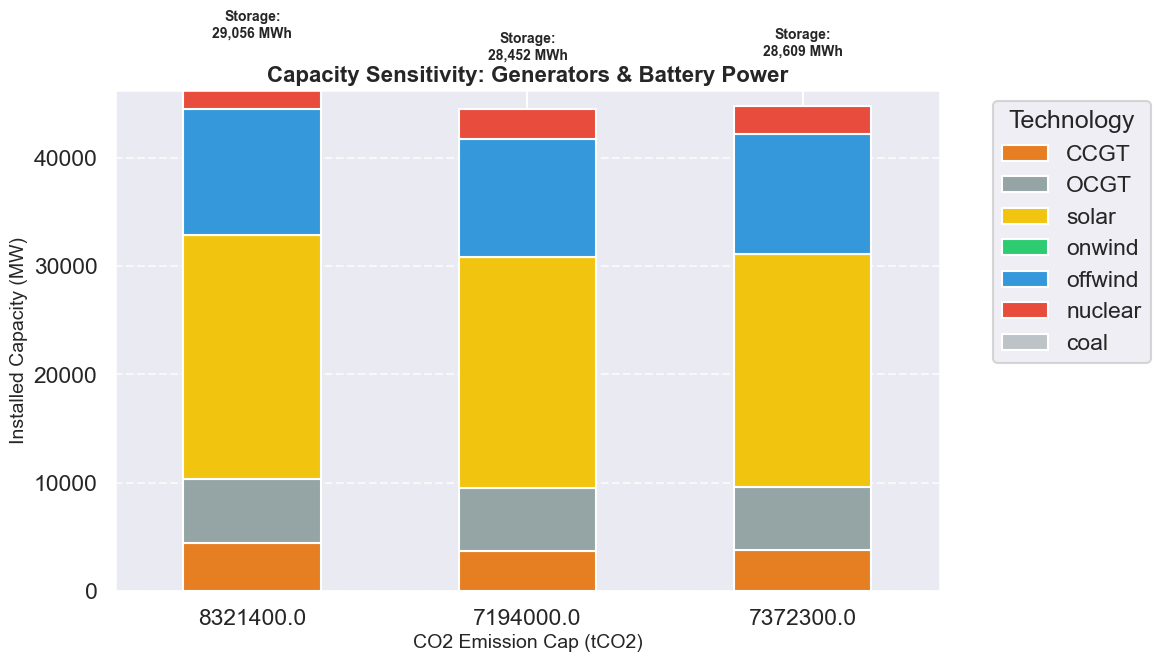

In [66]:
# 4. Results Extraction & Multi-Cap Analysis (with Battery Storage)
colors = {
    'CCGT': '#e67e22', 'OCGT': '#95a5a6', 'solar': '#f1c40f',
    'onwind': '#2ecc71', 'offwind': '#3498db', 'nuclear': '#e74c3c', 'coal': '#bdc3c7',
    'Battery_P': '#9b59b6', 'Battery_E': '#8e44ad' # Added battery colors
}

# --- Create Comparative DataFrames ---
# 1. Capacity DataFrame (Generators + Battery Power)
cap_data = {}
for cap_val in co2_caps:
    # Combine generator capacities and battery power capacity
    s = results[cap_val]['capacity'].copy()
    s['Battery_MW'] = results[cap_val]['batt_power']
    cap_data[cap_val] = s

df_cap_sensitivity = pd.DataFrame(cap_data).T
df_cap_sensitivity.index.name = 'CO2_Cap_tCO2'

# 2. General Metrics (Cost, Tax, Battery Energy)
metrics_data = []
for cap_val in co2_caps:
    res = results[cap_val]
    metrics_data.append({
        'CO2_Cap': cap_val,
        'Tax': abs(res['co2_price']),
        'Total_Cost': res['total_cost'],
        'Batt_Energy_MWh': res['batt_energy'],
        'Batt_Duration_h': res['batt_energy'] / res['batt_power'] if res['batt_power'] > 0 else 0
    })
df_metrics = pd.DataFrame(metrics_data).set_index('CO2_Cap')

# --- Detailed Console Output ---
print("\n" + "="*50)
print(f"{'CO2 SENSITIVITY SUMMARY (WITH STORAGE)':^50}")
print("="*50)

for cap_val in co2_caps:
    res = results[cap_val]
    tax = abs(res['co2_price'])

    print(f"\n[Cap: {cap_val/1e6:.2f} Mt CO2] -> Tax: {tax:.2f} EUR/tCO2 | Status: {res['status']}")
    print(f"{'-'*50}")
    print(f"  STORAGE: {res['batt_power']:8.2f} MW | {res['batt_energy']:8.2f} MWh")

    print("  GENERATION CAPACITIES (MW):")
    for tech, val in res['capacity'].items():
        if val > 1e-3: # Only print active techs
            print(f"    {tech:10}: {val:10.2f}")

    print(f"  Total System Cost: {res['total_cost']:,.2f} EUR")

# --- Visualization ---
import matplotlib.pyplot as plt

# Plot 1: Capacity Expansion (Stacked)
# Note: We use a different mapping for Battery Power in the plot
plot_colors = {**colors, 'Battery_MW': colors['Battery_P']}

ax = df_cap_sensitivity.plot(kind='bar', stacked=True, figsize=(12, 7), color=plot_colors)
plt.title('Capacity Sensitivity: Generators & Battery Power', fontsize=16, fontweight='bold')
plt.ylabel('Installed Capacity (MW)', fontsize=14)
plt.xlabel('CO2 Emission Cap (tCO2)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add Battery Energy info as text labels on top of bars
for i, (cap_val, row) in enumerate(df_metrics.iterrows()):
    plt.text(i, df_cap_sensitivity.iloc[i].sum(),
             f"Storage:\n{row['Batt_Energy_MWh']:,.0f} MWh",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

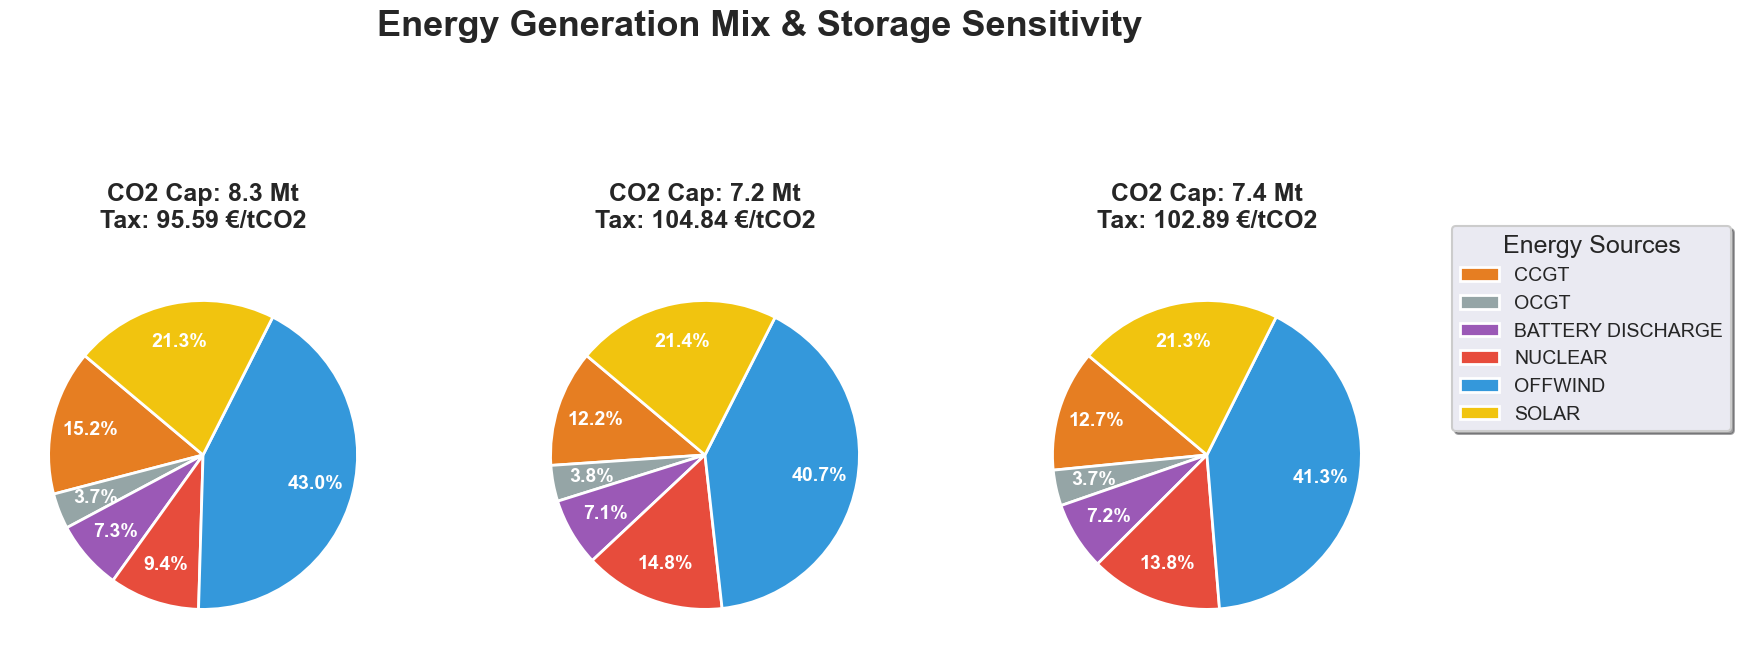

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use lowercase keys to make mapping more robust
colors = {
    'ccgt': '#e67e22',
    'ocgt': '#95a5a6',
    'solar': '#f1c40f',
    'onwind': '#2ecc71',
    'offwind': '#3498db',
    'nuclear': '#e74c3c',
    'coal': '#bdc3c7',
    'battery_mw': '#9b59b6',
    'battery': '#9b59b6',
    'battery_discharge': '#9b59b6'
}

# 1. Setup Style
sns.set_style("darkgrid")
sns.set_context("talk")

n_caps = len(co2_caps)
fig, axes = plt.subplots(1, n_caps, figsize=(20, 9), facecolor='white')

if n_caps == 1:
    axes = [axes]

for i, cap_val in enumerate(co2_caps):
    res = results[cap_val]

    # --- Data Preparation ---
    # Convert generator totals to a Series
    gen_data = res['generation_total'].copy()

    # Add Battery Discharge (ensure the key matches your colors dict)
    batt_total = res.get('battery_discharge_total', 0)
    if batt_total > 1:
        gen_data['battery_discharge'] = batt_total

    # Sort and filter negligible slices
    gen_data = gen_data.sort_index()
    gen_data = gen_data[gen_data > 10]

    # --- Color Mapping ---
    # Using .lower() ensures a match even if labels are inconsistent
    current_colors = [colors.get(tech.lower(), '#333333') for tech in gen_data.index]

    # --- Plotting ---
    tax = abs(res['co2_price'])
    wedges, texts, autotexts = axes[i].pie(
        gen_data,
        autopct='%1.1f%%',
        startangle=140,
        colors=current_colors,
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    plt.setp(autotexts, size=14, weight="bold", color="white")

    # Titles with Cap and Tax info
    title_text = f"CO2 Cap: {cap_val/1e6:.1f} Mt\nTax: {tax:.2f} €/tCO2"
    axes[i].set_title(title_text, fontsize=18, fontweight='bold', pad=25)

# 2. Unified Legend
fig.legend(
    wedges,
    [t.replace('_', ' ').upper() for t in gen_data.index], # Clean labels (e.g. BATTERY DISCHARGE)
    title="Energy Sources",
    title_fontsize=18,
    fontsize=14,
    loc="center right",
    borderaxespad=1,
    frameon=True,
    shadow=True
)

# 3. Final Formatting
plt.subplots_adjust(right=0.82, top=0.80, wspace=0.3)
plt.suptitle("Energy Generation Mix & Storage Sensitivity", fontsize=26, y=0.95, fontweight='bold')

plt.savefig('co2_battery_pies.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/04/070sw0zj27d4r6d6skj30gdw0000gn/T/ipykernel_22450/4132008815.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/04/070sw0zj27d4r6d6skj30gdw0000gn/T/ipykernel_22450/4132008815.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([t.upper().replace('_', ' ') for t in plot_order], rotation=45, fontsize=14)


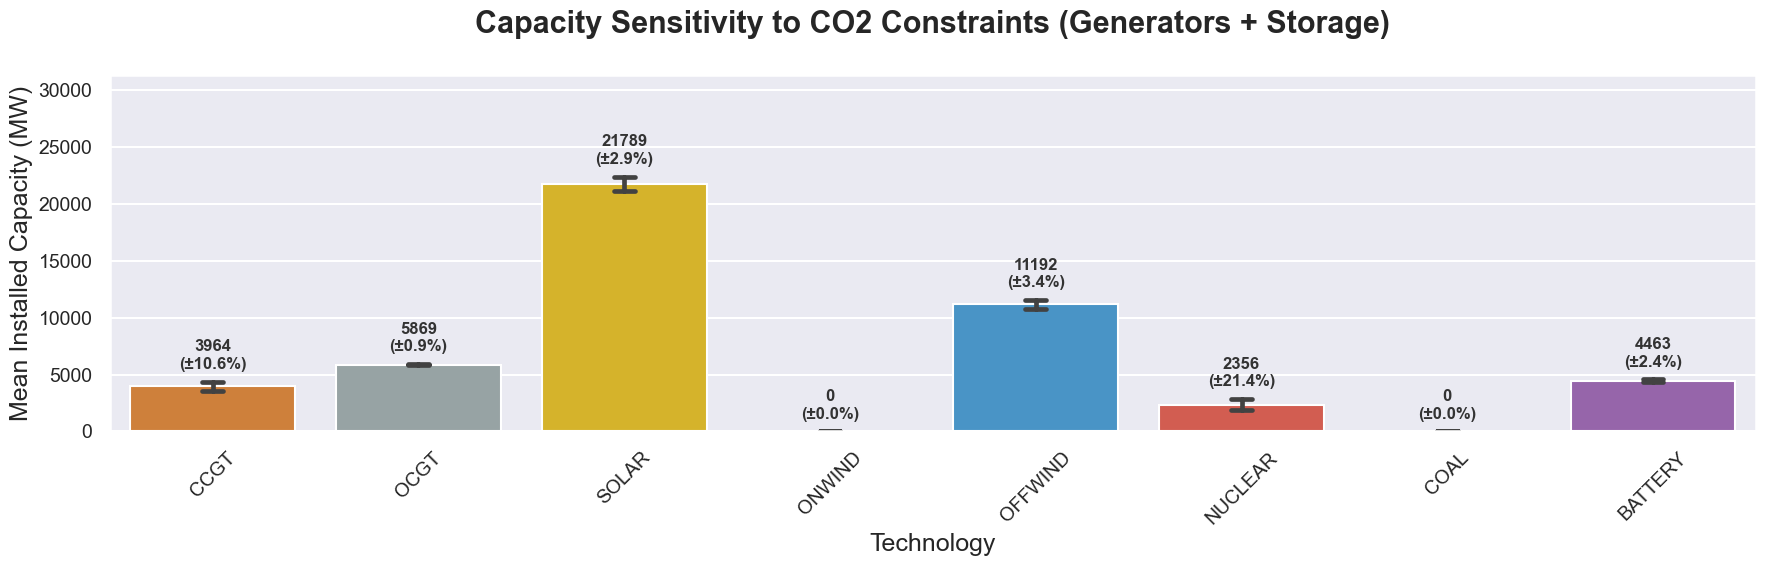

In [68]:
# 1. Aggregate results from all caps including Battery Power
all_caps_list = []
for cap_val, res in results.items():
    # Convert to series and then reset index
    temp_df = res['capacity'].reset_index()
    temp_df.columns = ['Technology', 'Capacity (MW)']

    # CRITICAL FIX: Ensure Technology column is strings, not xarray objects
    temp_df['Technology'] = temp_df['Technology'].astype(str)

    # Manually add Battery Power Capacity
    # res['batt_power'] is likely a DataArray, use .item() to get the number
    batt_val = res['batt_power'].item() if hasattr(res['batt_power'], 'item') else res['batt_power']
    battery_row = pd.DataFrame({'Technology': ['battery'], 'Capacity (MW)': [batt_val]})

    temp_df = pd.concat([temp_df, battery_row], ignore_index=True)
    all_caps_list.append(temp_df)

df_all_caps = pd.concat(all_caps_list)

# 2. Set global context
sns.set_style("darkgrid")
sns.set_context("talk")

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 6))

# Define technology order for consistent coloring (lowercase to match your dict)
# Updated plot_order logic to be safe
plot_order = [str(t) for t in df_all_caps['Technology'].unique()]
current_palette = [colors.get(t.lower(), '#333333') for t in plot_order]

sns.barplot(
    data=df_all_caps,
    x='Technology',
    y='Capacity (MW)',
    order=plot_order,
    errorbar='sd',
    capsize=.1,
    palette=current_palette,
    ax=ax
)

# 4. Synchronize Statistics
stats = df_all_caps.groupby('Technology')['Capacity (MW)'].agg(['mean', 'std'])
stats = stats.reindex(plot_order).reset_index()

# 4. Handle NaNs and calculate % deviation
stats['std'] = stats['std'].fillna(0)
stats['pct_dev'] = (stats['std'] / stats['mean'] * 100).fillna(0)

# 5. Add Synchronized Labels
for i, row in stats.iterrows():
    # Offset to keep labels above error bars
    y_pos = row['mean'] + row['std'] + (stats['mean'].max() * 0.04)
    label = f"{row['mean']:.0f}\n(±{row['pct_dev']:.1f}%)"

    ax.text(
        i, y_pos,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

# 6. Final Formatting
ax.set_title('Capacity Sensitivity to CO2 Constraints (Generators + Storage)', fontsize=22, fontweight='bold', pad=30)
ax.set_ylabel('Mean Installed Capacity (MW)', fontsize=18)
ax.set_xlabel('Technology', fontsize=18)

# Clean up X-axis labels (uppercase)
ax.set_xticklabels([t.upper().replace('_', ' ') for t in plot_order], rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Ensure Y-axis accounts for labels
plt.ylim(0, (stats['mean'] + stats['std']).max() * 1.4)

plt.tight_layout()
plt.savefig('plots/co2_mean_var.png')
plt.savefig('co2_mean_var_with_battery.png', dpi=300)
plt.show()